In [1]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from phisat2.data_loaders import build_datamodule
from phisat2.models.registry import build_model
from phisat2.tasks import resolve_task_spec
from phisat2.training.downstream import DownstreamModule
from phisat2.utils.seed import seed_everything
from phisat2.utils.visualization import visualize_downstream_demo

In [4]:
# ==========================
# CONFIG
# ==========================

# 1. Define Task and Dataset
TASK = "segmentation"       # Options: "segmentation", "pixel_regression", "classification"
DATASET = "lulc"          # Options: "lulc", "floods", "clouds", "burned", "roads", "building", "router"

# 2. Model and Weights
MODEL_NAME = "phisatnet"
CKPT_PATH = f"/lustre/home/u10010021/phisat2/runs/{TASK}/{DATASET}/terramind_v1_large/full_dataset/seed_42/checkpoints/best.ckpt"

# 3. Data
ROOT_DIR = "/lustre/home/u10010021/phisat2/data"
BATCH_SIZE = 4              
SEED = 42

In [5]:
seed_everything(SEED)

spec = resolve_task_spec(TASK, DATASET)

datamodule = build_datamodule(
    "downstream",
    root_dir=ROOT_DIR,
    spec=spec,
    batch_size=BATCH_SIZE,
    num_workers=2,
    seed=SEED,
    crop_size=256,
    fast_dev_run=False
)
datamodule.setup(stage="test")
test_loader = datamodule.test_dataloader()

bundle = build_model(
    MODEL_NAME, 
    spec, 
    pretrained=False, 
    input_bands=datamodule.input_bands
)

module = DownstreamModule.load_from_checkpoint(
    CKPT_PATH,
    model=bundle.model,
    spec=spec,
    lr=0.0,
    weight_decay=0.0,
    strict=True
)

module.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
module.to(device);

In [14]:
batch_index = 10000

for i, batch in enumerate(test_loader):
    if i == batch_index:    
        break

images_tensor = batch["image"].to(device)

module.eval()
with torch.no_grad():
    preds_tensor = module(images_tensor)

if TASK in ["segmentation", "classification"]:
    preds_np = preds_tensor.argmax(dim=1).cpu().numpy()
elif TASK == "pixel_regression":
    if preds_tensor.ndim == 4:
        preds_np = preds_tensor[:, 0, ...].cpu().numpy()
    else:
        preds_np = preds_tensor.cpu().numpy()

target_key = "mask" if "mask" in batch else spec.target_key
targets_tensor = batch[target_key]

if targets_tensor.ndim == 4:
    targets_np = targets_tensor[:, 0, ...].cpu().numpy()
else:
    targets_np = targets_tensor.cpu().numpy()

images_np = images_tensor.cpu().numpy()

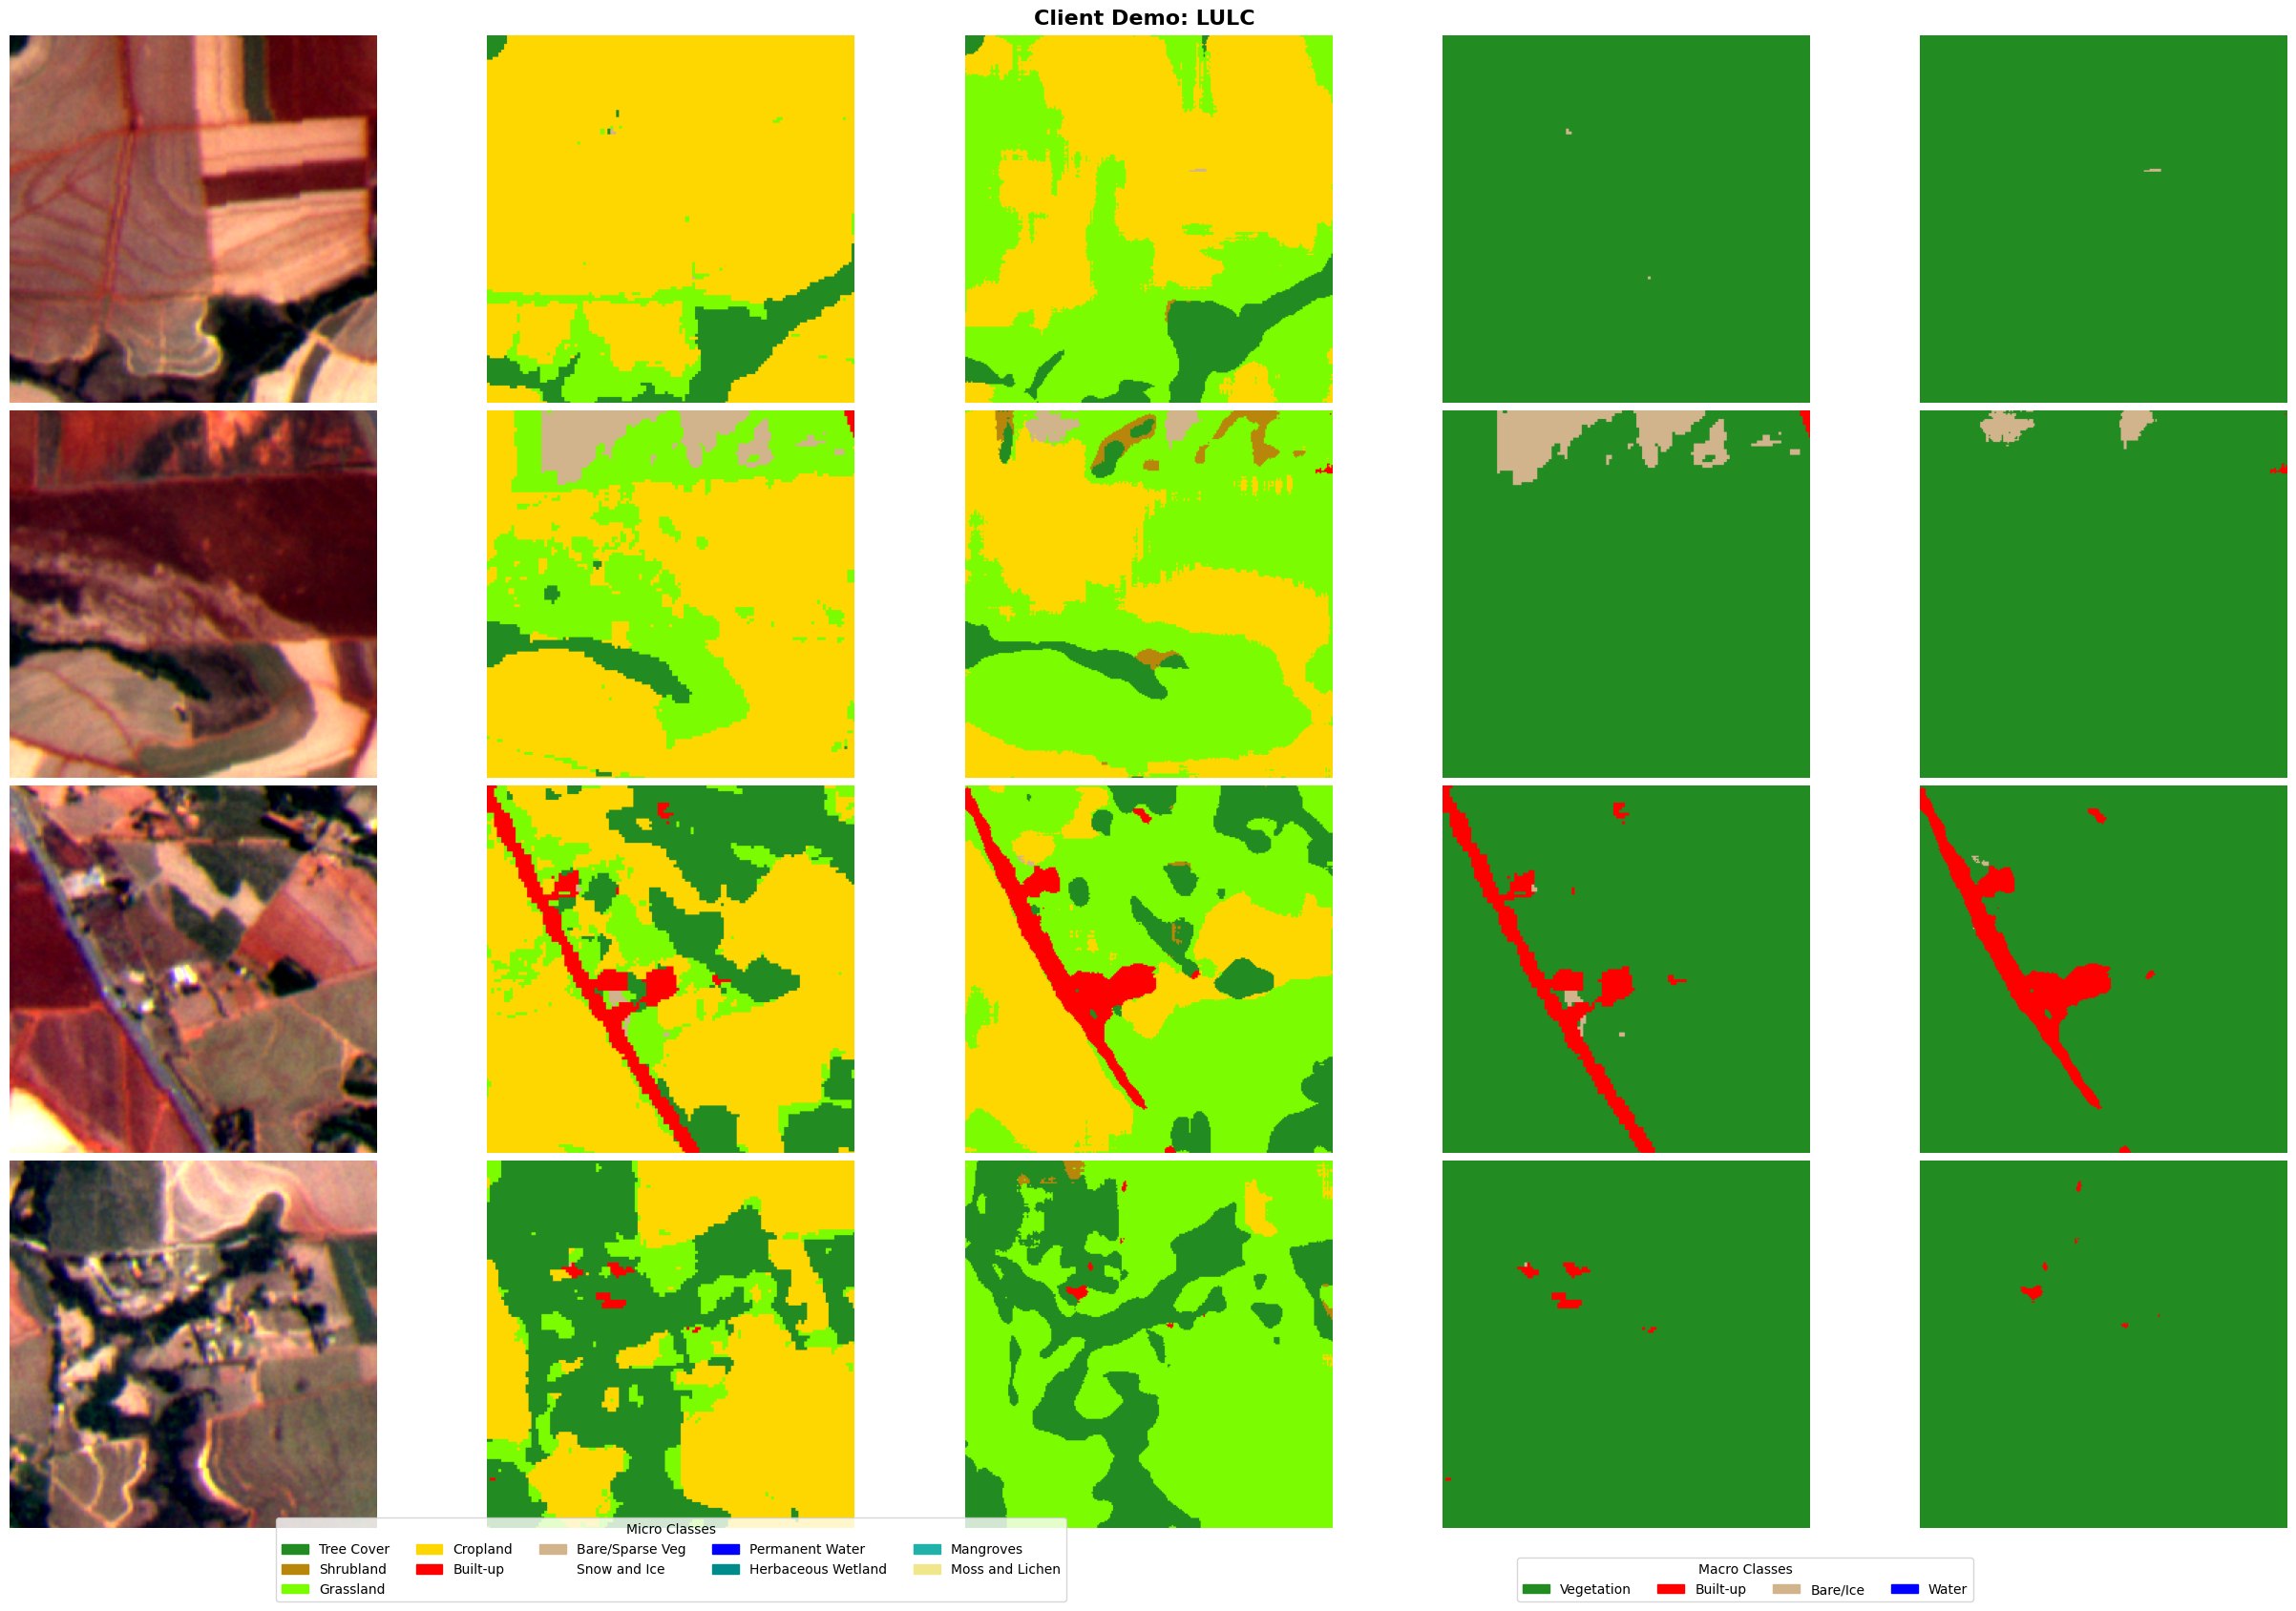

In [15]:
fig = visualize_downstream_demo(
    images=images_np,
    targets=targets_np,
    preds=preds_np,
    task_type=TASK,
    dataset_name=DATASET,
    max_samples=4
)